In [1]:
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW3')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
from sklearn.utils import resample
import statsmodels.api as sm
from pygam import LinearGAM, s
import warnings
import patsy
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('trees.csv') 
print(df.head(5))
print(df.shape)
print(df.columns.tolist())
girth = df['Girth'].values
print(girth.shape)
volume = df['Volume'].values
print(volume.shape)

   Girth  Height  Volume
0    8.3      70    10.3
1    8.6      65    10.3
2    8.8      63    10.2
3   10.5      72    16.4
4   10.7      81    18.8
(31, 3)
['Girth', 'Height', 'Volume']
(31,)
(31,)


Degree 1: Adjusted R² = 0.9331, 5-CV MSE = 19.9646
Degree 2: Adjusted R² = 0.9588, 5-CV MSE = 11.5521
Degree 3: Adjusted R² = 0.9586, 5-CV MSE = 22.8049
Degree 4: Adjusted R² = 0.9577, 5-CV MSE = 18.7334


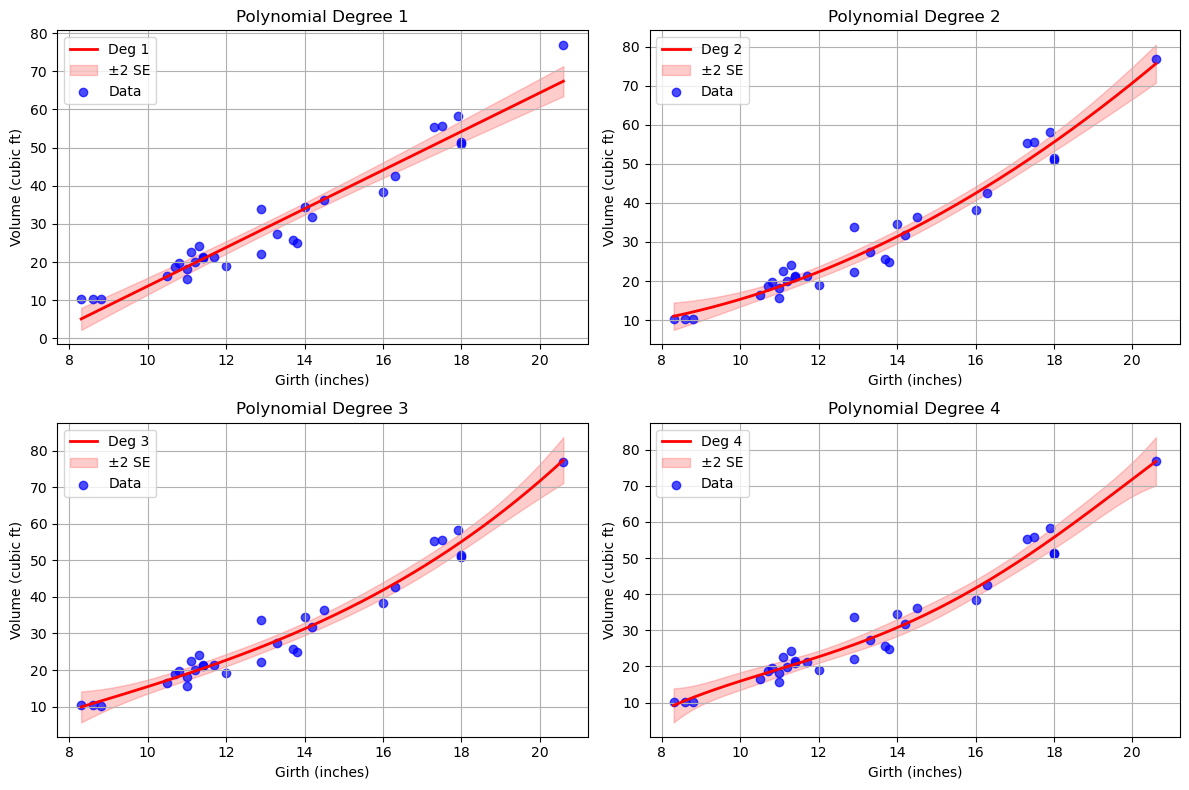

Final Model Selection:
Based on the largest adjust R-squared → Choose degree=2
Based on 5-CV MSE → Choose deg=2


In [2]:
# P2_Q1
# set up the degrees to evaluate
degrees = [1, 2, 3, 4]
adj_r2s = []
cv_errors = []

girth_smooth = np.linspace(girth.min(), girth.max(), 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly = poly.fit_transform(girth.reshape(-1, 1))  # shape: (31, deg)

    # use statsmodels to fit the model for adjusted R² calculation
    X_sm = sm.add_constant(X_poly)  
    model = sm.OLS(volume, X_sm).fit()
    
    # get adjusted R²
    adj_r2 = model.rsquared_adj
    adj_r2s.append(adj_r2)
    
    # calculate 5-fold CV MSE
    kf = KFold(n_splits=5, shuffle=True, random_state=3042)
    mse_list = []
    for train_idx, test_idx in kf.split(X_poly):
        X_train, X_test = X_poly[train_idx], X_poly[test_idx]
        y_train, y_test = volume[train_idx], volume[test_idx]
        
        X_train_sm = sm.add_constant(X_train)
        model_cv = sm.OLS(y_train, X_train_sm).fit()
        
        X_test_sm = sm.add_constant(X_test)
        y_pred = model_cv.predict(X_test_sm)
        
        mse = np.mean((y_test - y_pred) ** 2)
        mse_list.append(mse)
    
    cv_error = np.mean(mse_list)
    cv_errors.append(cv_error)
    
    print(f"Degree {deg}: Adjusted R² = {adj_r2:.4f}, 5-CV MSE = {cv_error:.4f}")
    
    X_smooth_poly = poly.transform(girth_smooth.reshape(-1, 1))
    X_smooth_sm = sm.add_constant(X_smooth_poly)
    
    # get predictions and confidence intervals
    pred = model.get_prediction(X_smooth_sm)
    pred_summary = pred.summary_frame(alpha=0.05)
    
    ax = axes[i]
    ax.plot(girth_smooth, pred_summary['mean'], 'r-', linewidth=2, label=f'Deg {deg}')
    ax.fill_between(girth_smooth,
                    pred_summary['mean'] - 2 * pred_summary['mean_se'], #±2 standard error
                    pred_summary['mean'] + 2 * pred_summary['mean_se'], #±2 standard error
                    color='red', alpha=0.2, label='±2 SE')
    ax.scatter(girth, volume, alpha=0.7, color='blue', label='Data')
    ax.set_title(f'Polynomial Degree {deg}')
    ax.set_xlabel('Girth (inches)')
    ax.set_ylabel('Volume (cubic ft)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# select the best models
best_deg_adj = degrees[np.argmax(adj_r2s)]
best_deg_cv = degrees[np.argmin(cv_errors)]

print("Final Model Selection:")
print(f"Based on the largest adjust R-squared → Choose degree={best_deg_adj}")
print(f"Based on 5-CV MSE → Choose deg={best_deg_cv}")


Logistic Regression Model Summary:
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   31
Model:                          Logit   Df Residuals:                       28
Method:                           MLE   Df Model:                            2
Date:                Sat, 08 Nov 2025   Pseudo R-squ.:                  0.7663
Time:                        09:42:13   Log-Likelihood:                -4.8345
converged:                       True   LL-Null:                       -20.690
Covariance Type:            nonrobust   LLR p-value:                 1.300e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6239    120.503      0.047      0.963    -230.558     241.806
x1            -3.3205     18.765     -0.177      0.860     -40.099      33.458
x2             0.

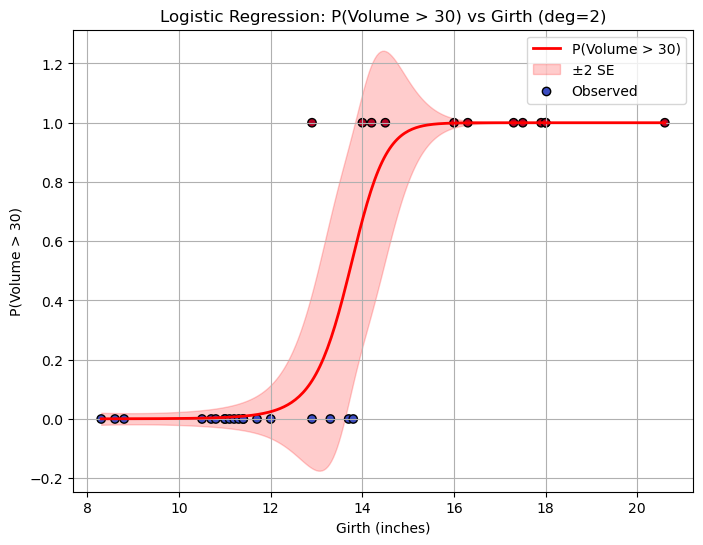

In [3]:
# P2_Q2
# set up binary response variable
y_binary = (volume > 30).astype(int)

poly_log = PolynomialFeatures(degree=2, include_bias=False)
X_poly_log = poly_log.fit_transform(girth.reshape(-1, 1))

# Logistic Regression
X_sm_log = sm.add_constant(X_poly_log)
model_log = sm.Logit(y_binary, X_sm_log).fit(disp=False) # not display fitting info

print("Logistic Regression Model Summary:")
print(model_log.summary())

girth_smooth = np.linspace(girth.min(), girth.max(), 300)

X_smooth_poly_log = poly_log.transform(girth_smooth.reshape(-1, 1))
X_smooth_sm_log = sm.add_constant(X_smooth_poly_log)

pred_log = model_log.get_prediction(X_smooth_sm_log)
pred_log_summary = pred_log.summary_frame(alpha=0.05)
print(pred_log_summary.columns.tolist())

# 逻辑回归里用predict和se
prob_pred = pred_log_summary['predicted']  # P(Volume > 30)
se_pred = pred_log_summary['se']

# plot
plt.figure(figsize=(8, 6))
plt.plot(girth_smooth, prob_pred, 'r-', linewidth=2, label='P(Volume > 30)')
plt.fill_between(girth_smooth,
                 prob_pred - 2 * se_pred,
                 prob_pred + 2 * se_pred,
                 color='red', alpha=0.2, label='±2 SE')
plt.scatter(girth, y_binary, c=y_binary, cmap='coolwarm', edgecolors='k', label='Observed')
plt.xlabel('Girth (inches)')
plt.ylabel('P(Volume > 30)')
plt.title('Logistic Regression: P(Volume > 30) vs Girth (deg=2)')
plt.legend()
plt.grid(True)
plt.show()


The Summary of Regression Spline：
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     130.1
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           4.60e-17
Time:                        09:42:13   Log-Likelihood:                -79.163
No. Observations:                  31   AIC:                             170.3
Df Residuals:                      25   BIC:                             178.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

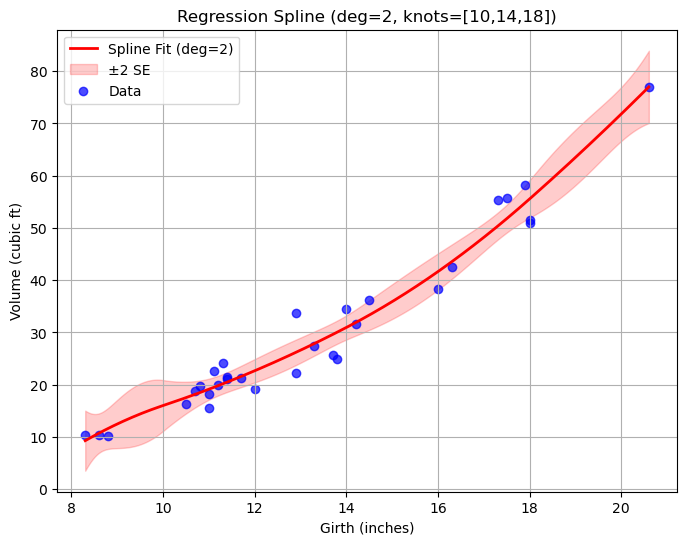

In [4]:
# P2_Q3
knots = [10, 14, 18]

# 3. 构建样条设计矩阵（二次样条）
# formula: bs(Girth, knots=knots, degree=2, include_intercept=True)
formula = "bs(Girth, knots=knots, degree=2, include_intercept=True)"
X_spline = patsy.dmatrix(formula, {"Girth": girth}, return_type='dataframe')

model_spline = sm.OLS(volume, X_spline).fit()

print("The Summary of Regression Spline：")
print(model_spline.summary())


girth_smooth = np.linspace(girth.min(), girth.max(), 300)
X_smooth_spline = patsy.dmatrix(formula, {"Girth": girth_smooth}, return_type='dataframe')


pred_spline = model_spline.get_prediction(X_smooth_spline)
pred_spline_summary = pred_spline.summary_frame(alpha=0.05)
print(pred_spline_summary.columns.tolist())

y_pred = pred_spline_summary['mean']
se_pred = pred_spline_summary['mean_se']

# Plot
plt.figure(figsize=(8, 6))
plt.plot(girth_smooth, y_pred, 'r-', linewidth=2, label='Spline Fit (deg=2)')
plt.fill_between(girth_smooth,
                 y_pred - 2 * se_pred,
                 y_pred + 2 * se_pred,
                 color='red', alpha=0.2, label='±2 SE')
plt.scatter(girth, volume, alpha=0.7, color='blue', label='Data')
plt.xlabel('Girth (inches)')
plt.ylabel('Volume (cubic ft)')
plt.title('Regression Spline (deg=2, knots=[10,14,18])')
plt.legend()
plt.grid(True)
plt.show()

(31, 1)
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                       4.544
Link Function:                     IdentityLink Log Likelihood:                                  -104.5332
Number of Samples:                           31 AIC:                                              220.1545
                                                AICc:                                             223.1215
                                                GCV:                                               15.1171
                                                Scale:                                             11.1894
                                                Pseudo R-Squared:                                   0.9635
Feature Function             

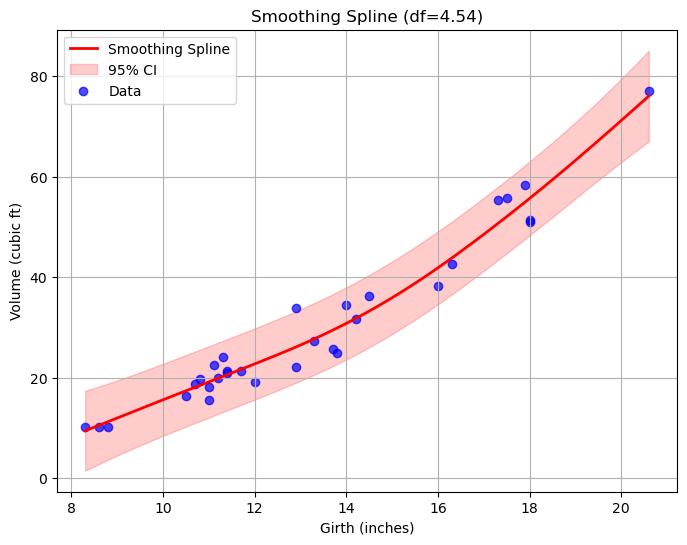

In [5]:
# P2_Q4

# transfer girth into 2D array
girth_2d = girth.reshape(-1, 1)
print(girth_2d.shape)

# fit GAM model
gam_smoother = LinearGAM(s(0, n_splines=10))
gam_smoother.fit(girth_2d, volume)
gam_smoother.summary()

# get effective degrees of freedom used
df_used = gam_smoother.statistics_['edof']
print(f" effective degrees of freedom used = {df_used:.2f}")

# get predictions and confidence intervals
girth_smooth = np.linspace(girth_2d.min(), girth_2d.max(), 300).reshape(-1, 1)
pred_gam = gam_smoother.predict(girth_smooth)
conf_int = gam_smoother.prediction_intervals(girth_smooth, width=0.95)

# plot
plt.figure(figsize=(8, 6))
plt.plot(girth_smooth, pred_gam, 'r-', linewidth=2, label='Smoothing Spline')
plt.fill_between(girth_smooth.flatten(),
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color='red', alpha=0.2, label='95% CI')
plt.scatter(girth_2d, volume, alpha=0.7, color='blue', label='Data')
plt.xlabel('Girth (inches)')
plt.ylabel('Volume (cubic ft)')
plt.title(f'Smoothing Spline (df={df_used:.2f})')
plt.legend()
plt.grid(True)
plt.show()

(31, 2)
dict_keys(['n_samples', 'm_features', 'edof_per_coef', 'edof', 'scale', 'cov', 'se', 'AIC', 'AICc', 'pseudo_r2', 'GCV', 'UBRE', 'loglikelihood', 'deviance', 'p_values'])
Target df: Girth=4, Height=5
Actual edof: Girth=2.71, Height=1.51


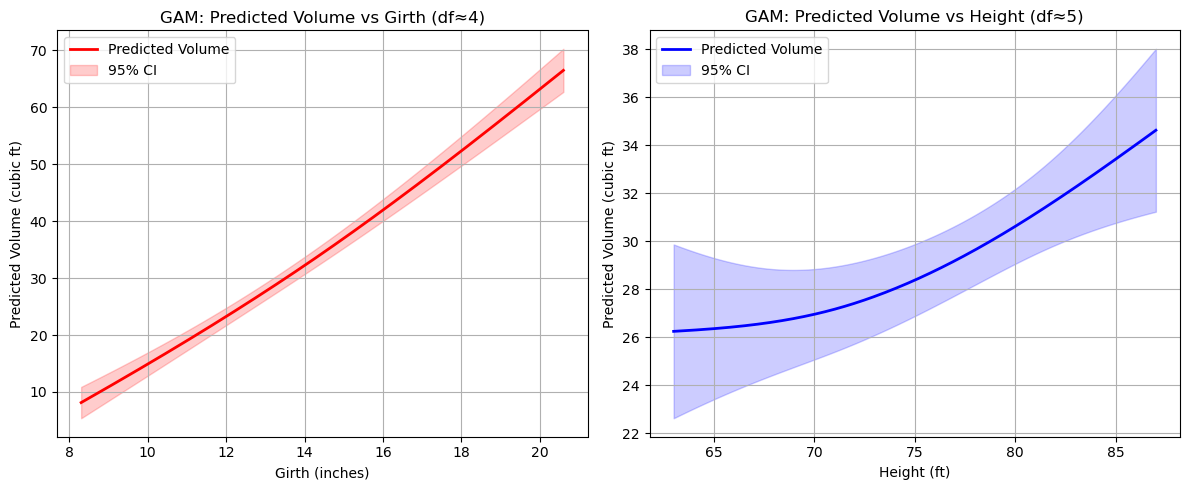

In [6]:
# P2_Q5

# prepare 2D input data
X_gam_2d = df[['Girth', 'Height']].values  # shape: (31, 2)
print(X_gam_2d.shape)

# fit GAM model
# Girth is a smoothing spline with df=4 and the function on Height is a smoothing spline with df=5
# edof ≈ n_splines - 1 so we set n_splines=5 for Girth and n_splines=6 for Height
gam_2d = LinearGAM(s(0, n_splines=5) + s(1, n_splines=6))

gam_2d.fit(X_gam_2d, volume)
print(gam_2d.statistics_.keys())

# get the freedom used
if 'edof_per_coef' in gam_2d.statistics_:
    edof_per_coef = gam_2d.statistics_['edof_per_coef']
    edof_girth = np.sum(edof_per_coef[:5])  # 前5个系数属于Girth
    edof_height = np.sum(edof_per_coef[5:])  # 后6个系数属于Height
    print(f"Target df: Girth=4, Height=5")
    print(f"Actual edof: Girth={edof_girth:.2f}, Height={edof_height:.2f}")
else:
    print("Warning: 'edof_per_coef' not available. Reporting total edof.")
    print(f"Total edof: {gam_2d.statistics_['edof']:.2f}")

plt.figure(figsize=(12, 5))

# Girth 的函数图（固定 Height 为均值）
plt.subplot(1, 2, 1)
girth_plot = np.linspace(girth.min(), girth.max(), 300)
X_girth_only = np.column_stack([girth_plot, np.full_like(girth_plot, df['Height'].mean())])

pred_girth_full = gam_2d.predict(X_girth_only)
conf_int_girth = gam_2d.confidence_intervals(X_girth_only)

plt.plot(girth_plot, pred_girth_full, 'r-', linewidth=2, label='Predicted Volume')
plt.fill_between(girth_plot,
                 conf_int_girth[:, 0],
                 conf_int_girth[:, 1],
                 color='red', alpha=0.2, label='95% CI')
plt.xlabel('Girth (inches)')
plt.ylabel('Predicted Volume (cubic ft)')
plt.title('GAM: Predicted Volume vs Girth (df≈4)')
plt.legend()
plt.grid(True)

# Height 的函数图（固定 Girth 为均值）
plt.subplot(1, 2, 2)
height_plot = np.linspace(df['Height'].min(), df['Height'].max(), 300)
X_height_only = np.column_stack([np.full_like(height_plot, df['Girth'].mean()), height_plot])

pred_height_full = gam_2d.predict(X_height_only)
conf_int_height = gam_2d.confidence_intervals(X_height_only)

plt.plot(height_plot, pred_height_full, 'b-', linewidth=2, label='Predicted Volume')
plt.fill_between(height_plot,
                 conf_int_height[:, 0],
                 conf_int_height[:, 1],
                 color='blue', alpha=0.2, label='95% CI')
plt.xlabel('Height (ft)')
plt.ylabel('Predicted Volume (cubic ft)')
plt.title('GAM: Predicted Volume vs Height (df≈5)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()